In [80]:
import numpy as np
import matplotlib.pyplot as plt

Text(0, 0.5, 'Range')

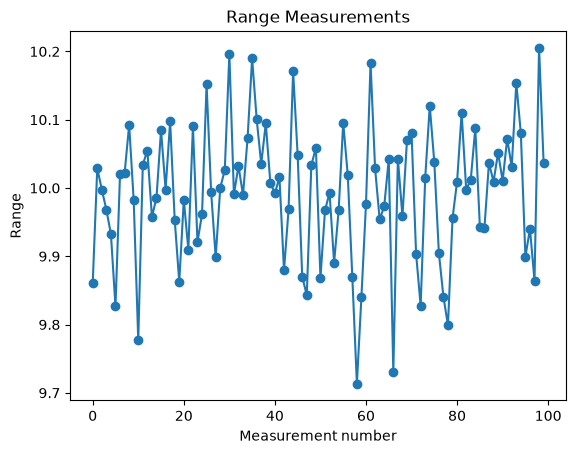

In [81]:
actual_range = 10
num_measurements = 100

measurement_range = np.random.normal(actual_range, 0.1, num_measurements)

plt.plot(measurement_range,'o-')
plt.title('Range Measurements')
plt.xlabel('Measurement number')
plt.ylabel('Range')

In [82]:
R = 0.01 # Measured Covariance
c = 0.0001 # Process Covariance

x=np.zeros(num_measurements)
p=np.zeros(num_measurements)
x_minus=np.zeros(num_measurements)
p_minus=np.zeros(num_measurements)
k_gain=np.zeros(num_measurements)

In [83]:
# Initialize filter variables
x[0]=0
p[0]=1

In [84]:
for i in range(1,num_measurements):
    x_minus[i] = x[i-1]
    p_minus[i] = p[i-1] + c

    k_gain[i] = p_minus[i] / (p_minus[i]+R)
    x[i] = x_minus[i] + k_gain[i] * (measurement_range[i] - x_minus[i])
    p[i] = (1-k_gain[i]) * p_minus[i]
    


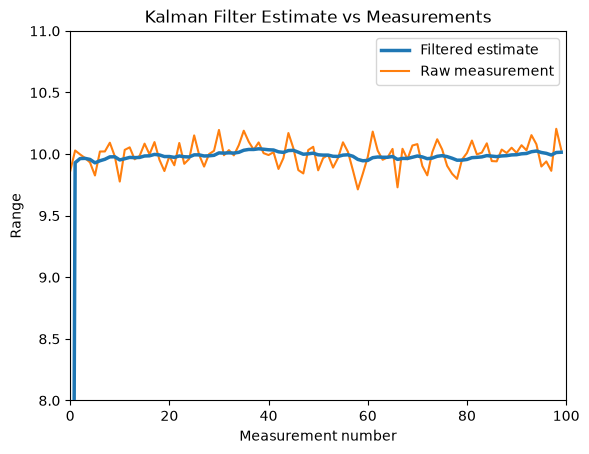

In [85]:
plt.plot(x,linewidth=2.5,zorder=3)
plt.plot(measurement_range)
plt.axis([0,100,8,11])
plt.title('Kalman Filter Estimate vs Measurements')
plt.xlabel('Measurement number')
plt.ylabel('Range')
plt.legend(['Filtered estimate', 'Raw measurement'])

Text(0, 0.5, 'P')

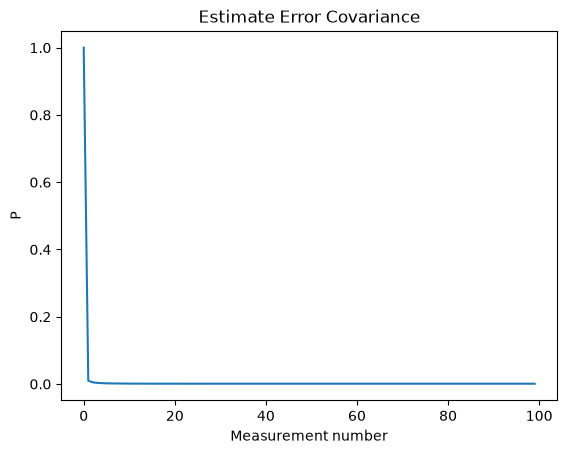

In [86]:
plt.plot(p)
plt.title('Estimate Error Covariance')
plt.xlabel('Measurement number')
plt.ylabel('P')

## Exercise 2: 2D Constant-Velocity Kalman Filter (matrix form)

State vector `x = [position, velocity]`. Only position is measured; velocity is inferred by the filter.
Fill in the TODOs below yourself — the scaffolding just sets up the simulation and matrices.

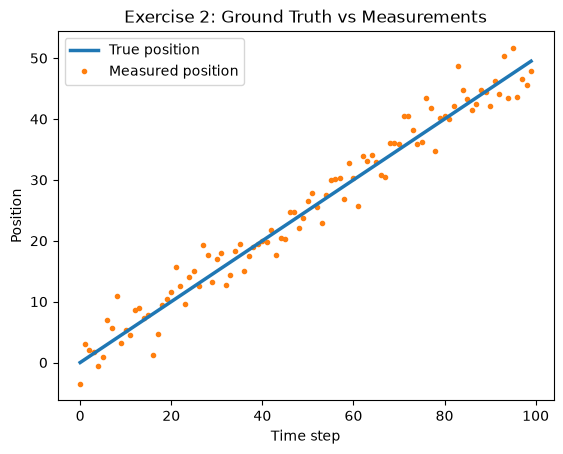

In [87]:
# --- Simulate ground truth ---
dt = 1.0                      # time step
num_steps = 100

true_velocity = 0.5
true_position = np.zeros(num_steps)
for i in range(1, num_steps):
    true_position[i] = true_position[i-1] + true_velocity * dt

position_measurement_noise_std = 2.5
position_measurements = true_position + np.random.normal(0, position_measurement_noise_std, num_steps)

plt.plot(true_position, label='True position', linewidth=2.5, zorder=3)
plt.plot(position_measurements, '.', label='Measured position')
plt.title('Exercise 2: Ground Truth vs Measurements')
plt.xlabel('Time step')
plt.ylabel('Position')
plt.legend()

In [88]:
# --- Kalman filter matrices ---
# State: x = [position, velocity]

F = np.array([[1, dt],
              [0, 1]])          # state transition matrix

H = np.array([[1, 0]])          # measurement matrix (we only observe position)

Q = np.array([[1e-4, 0],
              [0, 1e-4]])       # process noise covariance

R = np.array([[position_measurement_noise_std**2]])  # measurement noise covariance

x0 = np.array([0, 0])           # initial state [position, velocity]
P0 = np.eye(2)                 # initial state covariance

In [89]:
# --- Storage for results ---
x_est = np.zeros((num_steps, 2))   # estimated [position, velocity] at each step
P_est = np.zeros((num_steps, 2, 2))

x_est[0] = x0
P_est[0] = P0

I = np.eye(len(F))

In [90]:
#--- todo: implement the predict/update loop ---
for i in range(1, num_steps):
    # Predict
    x_pred = F @ x_est[i-1]      # F @ x_est[i-1]
    P_pred = F @ P_est[i-1] @ F.T + Q      # F @ P_est[i-1] @ F.T + Q

    # Update
    y = position_measurements[i] - H @ x_pred            # measurement residual: position_measurements[i] - H @ x_pred
    S = H @ P_pred @ H.T + R            # residual covariance: H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)             # Kalman gain: P_pred @ H.T @ inv(S)
    x_est[i] = x_pred + K @ y        # x_pred + K @ y
    P_est[i] = (I - K @ H) @ P_pred         # (I - K @ H) @ P_pred
    pass

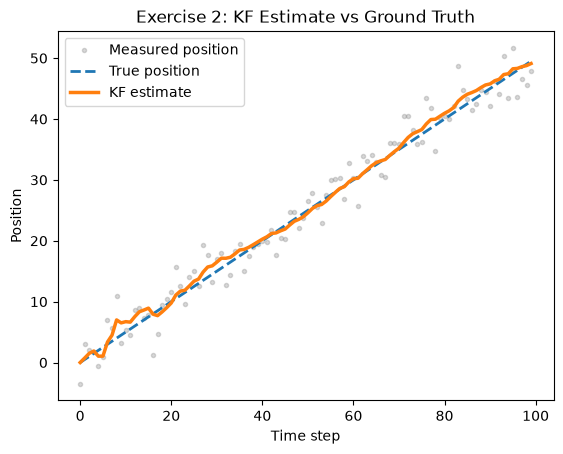

In [91]:
# --- TODO: plot results (estimated position/velocity vs truth) ---
plt.plot(position_measurements, '.', label='Measured position', color='gray', alpha=0.3, zorder=1)
plt.plot(true_position, label='True position', linewidth=2, linestyle='--', zorder=2)
plt.plot(x_est[:,0], label='KF estimate', linewidth=2.5, zorder=3)
plt.title('Exercise 2: KF Estimate vs Ground Truth')
plt.xlabel('Time step')
plt.ylabel('Position')
plt.legend()

Text(0, 0.5, 'P[position, position]')

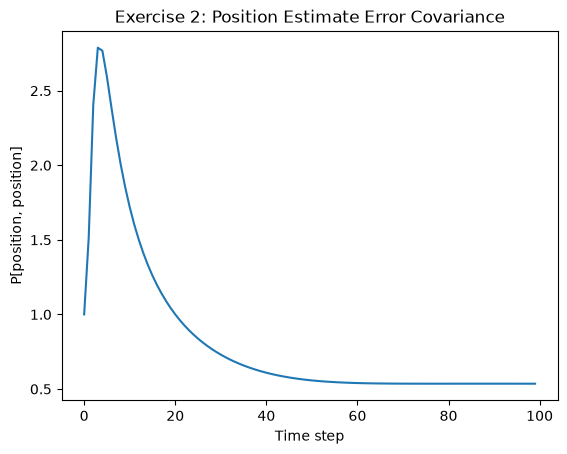

In [92]:
# --- Estimate error covariance (position uncertainty) ---
plt.plot(P_est[:, 0, 0])
plt.title('Exercise 2: Position Estimate Error Covariance')
plt.xlabel('Time step')
plt.ylabel('P[position, position]')

Text(0, 0.5, 'True - Estimated position')

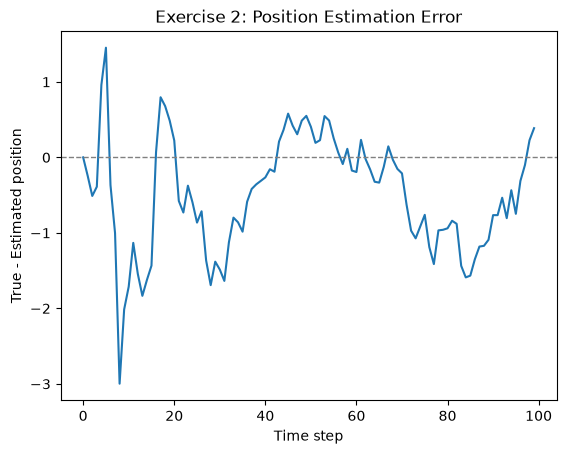

In [93]:
# --- Estimation error over time (true - estimated position) ---
position_error = true_position - x_est[:, 0]

plt.plot(position_error)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Exercise 2: Position Estimation Error')
plt.xlabel('Time step')
plt.ylabel('True - Estimated position')
